In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/meruvakodandasuraj/e-commerce-customer-behavior-and-sales-20202026/product_summary.csv
/kaggle/input/datasets/meruvakodandasuraj/e-commerce-customer-behavior-and-sales-20202026/monthly_revenue.csv
/kaggle/input/datasets/meruvakodandasuraj/e-commerce-customer-behavior-and-sales-20202026/orders.csv
/kaggle/input/datasets/meruvakodandasuraj/e-commerce-customer-behavior-and-sales-20202026/customers.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/datasets/meruvakodandasuraj/e-commerce-customer-behavior-and-sales-20202026/customers.csv')

In [4]:
df

,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.8,0,0,1,0
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.2,0,8,1,0
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.0,4,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,C07996,United States,36,Male,Gold,2025-07-09,13,1953.76,175.38,40,Jewelry & Accessories,Tablet,Debit Card,Social Media,1,4.4,1,14,1,1
7996,C07997,India,42,Male,Free,2025-06-28,31,6772.20,251.76,53,Electronics,Mobile,Credit Card,Paid Ad,12,4.6,4,1,0,0
7997,C07998,India,34,Male,Platinum,2026-02-01,46,2430.09,58.01,18,Home & Kitchen,Desktop,Cryptocurrency,Organic Search,9,4.2,6,0,1,0
7998,C07999,Japan,44,Female,Free,2026-01-15,35,5552.56,147.22,50,Food & Grocery,Mobile,Credit Card,Paid Ad,10,4.1,1,2,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               8000 non-null   object 
 1   country                   8000 non-null   object 
 2   age                       8000 non-null   int64  
 3   gender                    8000 non-null   object 
 4   membership_tier           8000 non-null   object 
 5   registration_date         8000 non-null   object 
 6   total_orders              8000 non-null   int64  
 7   total_spend_usd           8000 non-null   float64
 8   avg_order_value_usd       8000 non-null   float64
 9   days_since_last_purchase  8000 non-null   int64  
 10  preferred_category        8000 non-null   object 
 11  preferred_device          8000 non-null   object 
 12  preferred_payment_method  8000 non-null   object 
 13  acquisition_channel       8000 non-null   object 
 14  reviews_

dtypes of all the features seems to be okay, except the registration_date which needs to be converted to datetime.

There is no missing values.

In [6]:
df['registration_date'] = pd.to_datetime(df["registration_date"])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_id               8000 non-null   object        
 1   country                   8000 non-null   object        
 2   age                       8000 non-null   int64         
 3   gender                    8000 non-null   object        
 4   membership_tier           8000 non-null   object        
 5   registration_date         8000 non-null   datetime64[ns]
 6   total_orders              8000 non-null   int64         
 7   total_spend_usd           8000 non-null   float64       
 8   avg_order_value_usd       8000 non-null   float64       
 9   days_since_last_purchase  8000 non-null   int64         
 10  preferred_category        8000 non-null   object        
 11  preferred_device          8000 non-null   object        
 12  preferred_payment_me

In [8]:
df.describe(include = 'number')

,age,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,35.616375,16.545250,1558.642350,94.845566,59.583875,3.228750,4.109112,0.849500,4.457125,0.617375,0.089375
std,11.170455,14.681064,2284.094953,78.992885,60.610355,3.942698,0.523992,1.407337,4.854391,0.486058,0.285302
min,18.000000,1.000000,4.890000,5.000000,0.000000,0.000000,1.800000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,5.000000,336.055000,44.690000,16.000000,0.000000,3.800000,0.000000,1.000000,0.000000,0.000000
50%,35.000000,12.000000,845.700000,72.270000,41.000000,2.000000,4.200000,0.000000,3.000000,1.000000,0.000000
75%,43.000000,23.000000,1892.165000,118.560000,84.000000,5.000000,4.500000,1.000000,6.000000,1.000000,0.000000
max,75.000000,79.000000,61282.480000,1051.730000,582.000000,28.000000,5.000000,11.000000,41.000000,1.000000,1.000000


In [9]:
num_columns = df.select_dtypes(include = "number").columns

In [10]:
num_columns = list(num_columns)

In [11]:
del num_columns[-2:]
num_columns

['age',
 'total_orders',
 'total_spend_usd',
 'avg_order_value_usd',
 'days_since_last_purchase',
 'reviews_given',
 'avg_review_score',
 'returns_made',
 'wishlist_items']

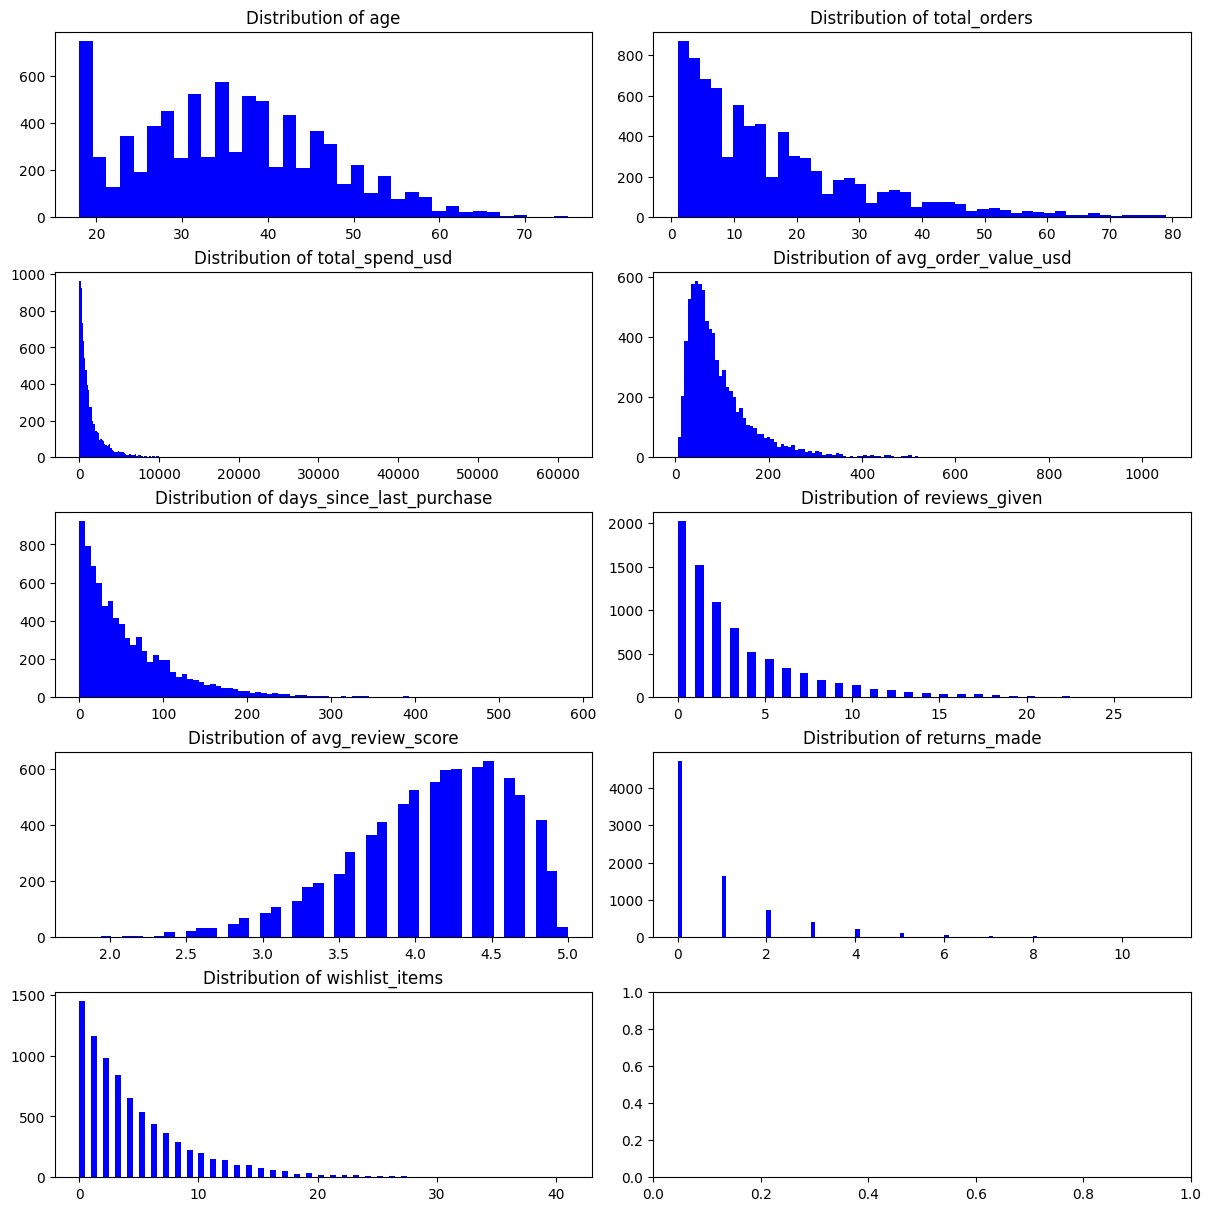

In [12]:
import math
ncols = 2
nrows = math.ceil(len(num_columns)/ncols)

fig, axes = plt.subplots(nrows = nrows,ncols = ncols,constrained_layout = True,figsize = (12,12)) 
axes = axes.flatten()

for i,col in enumerate(num_columns):
    axes[i].hist(df[col], bins = 'auto',color = 'blue')
    axes[i].set_title(f'Distribution of {col}')

# **Categorical Variables**

In [13]:
cat_columns = list(df.select_dtypes(include = 'object').columns)

cat_columns.extend(['newsletter_subscribed','churned'])

cat_columns

['customer_id',
 'country',
 'gender',
 'membership_tier',
 'preferred_category',
 'preferred_device',
 'preferred_payment_method',
 'acquisition_channel',
 'newsletter_subscribed',
 'churned']

In [14]:
from scipy.stats.contingency import chi2_contingency
from itertools import combinations

pairs = list(combinations(cat_columns,2))

def check_significance(df,col1,col2):
    crosstab = pd.crosstab(col1,col2)
    chi2,p,dof,expected = chi2_contingency(crosstab)
    return p

for col1,col2 in pairs:
    p_value = check_significance(df,df[col1],df[col2])
    if p_value < 0.05:
        print(f"significance relationship found: {col1} vs {col2} p_value({p_value})")

    

significance relationship found: gender vs preferred_payment_method p_value(0.011475867974172403)
significance relationship found: membership_tier vs churned p_value(0.012921742905867747)


**Safety Check on the significance**

In [15]:
for col1, col2 in pairs:
    p_value = check_significance(df, df[col1], df[col2])
    # Print everything to see the distribution of results
    print(f"{col1} vs {col2}: p={p_value:.4f}")
    
    if p_value < 0.05:
        print(" -> SIGNIFICANT!")

customer_id vs country: p=0.4858
customer_id vs gender: p=0.4941
customer_id vs membership_tier: p=0.4933
customer_id vs preferred_category: p=0.4880
customer_id vs preferred_device: p=0.4941
customer_id vs preferred_payment_method: p=0.4914
customer_id vs acquisition_channel: p=0.4920
customer_id vs newsletter_subscribed: p=0.4947
customer_id vs churned: p=0.4947
country vs gender: p=0.4385
country vs membership_tier: p=0.9497
country vs preferred_category: p=0.8545
country vs preferred_device: p=0.6395
country vs preferred_payment_method: p=0.7820
country vs acquisition_channel: p=0.4359
country vs newsletter_subscribed: p=0.9646
country vs churned: p=0.1444
gender vs membership_tier: p=0.2314
gender vs preferred_category: p=0.1670
gender vs preferred_device: p=0.0801
gender vs preferred_payment_method: p=0.0115
 -> SIGNIFICANT!
gender vs acquisition_channel: p=0.2390
gender vs newsletter_subscribed: p=0.6504
gender vs churned: p=0.9291
membership_tier vs preferred_category: p=0.3992

In [16]:
def cramers_v(df,col1,col2):
    crosstab = pd.crosstab(df[col1],df[col2])
    chi2,_,_,_ = chi2_contingency(crosstab)
    n = crosstab.sum().sum()
    r,c = crosstab.shape 
    return np.sqrt(chi2/(n*min((r-1),(c-1))))    

In [17]:
score = cramers_v(df,'gender','preferred_payment_method')
print(f"Cramers v score between gender and preferred payment method is {score:.4f}")

Cramers v score between gender and preferred payment method is 0.0402


<Axes: title={'center': 'Association between Gender and Preferred payment method'}, xlabel='preferred_payment_method', ylabel='gender'>

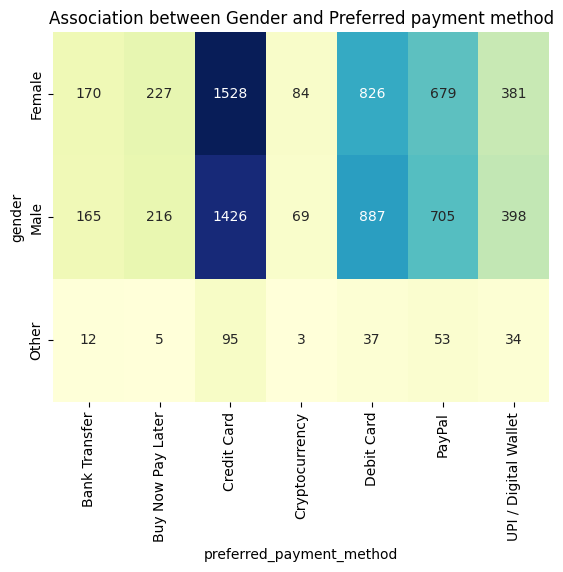

In [18]:
crosstab = pd.crosstab(df['gender'],df['preferred_payment_method'])
plt.title("Association between Gender and Preferred payment method")
sns.heatmap(crosstab,annot=True, cmap="YlGnBu", fmt='d', cbar=False) 

From the frequency table and the chi square test for independene:



In [19]:
score_2 = cramers_v(df,'membership_tier','churned')
print(f"Cramer's V score between Membership_tier and churned is {score_2:.4f}")

Cramer's V score between Membership_tier and churned is 0.0367


<Axes: xlabel='churned', ylabel='membership_tier'>

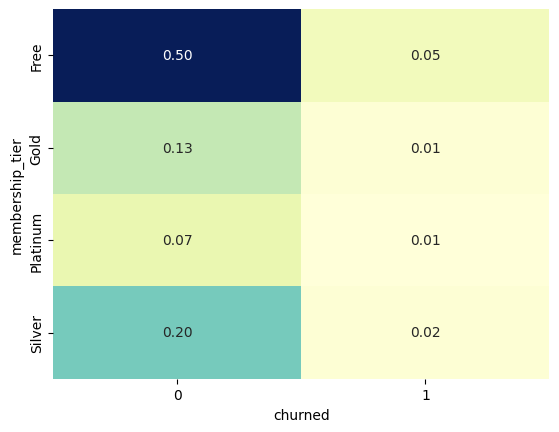

In [20]:
crosstab_2 = pd.crosstab(df['membership_tier'],df['churned'],normalize = 'all')
sns.heatmap(crosstab_2,annot = True, cmap="YlGnBu", fmt='.2f', cbar=False) 

Have to check the trend of the no. of churners in each of the categories across time to have a better understanding on how the membership_tier is performing as the churning may be because of reasons other than the service.

Lets check for adjusted Creamer's V score

In [21]:
def adjusted_cramers_v(df,col1,col2):
    crosstab = pd.crosstab(df[col1],df[col2])
    chi2,_,_,_ = chi2_contingency(crosstab)
    n = crosstab.sum().sum()
    r,c = crosstab.shape
    phi2 = max(0,(chi2/n)-((r-1)*(c-1)/(n-1)))
    r2 = r-((r-1)**2/(n-1))
    c2 = c- ((c-1)**2/(n-1))
    return np.sqrt(phi2/min((r2-1),(c2-1)))

In [22]:
adjusted_score = adjusted_cramers_v(df,'gender','preferred_payment_method')
print(f"The adjusted Cramer's V score between Gender and Preferred payment method was {adjusted_score:0.4f}")

The adjusted Cramer's V score between Gender and Preferred payment method was 0.0294


In [23]:
adjusted_score = adjusted_cramers_v(df,'membership_tier','churned')
print(f"The adjusted Cramer's V score between membership tier and churned was {adjusted_score:0.4f}")

The adjusted Cramer's V score between membership tier and churned was 0.0312


# Continuous variables

Text(0.5, 1.0, 'Correlation among continuous variables - Pearson correlation')

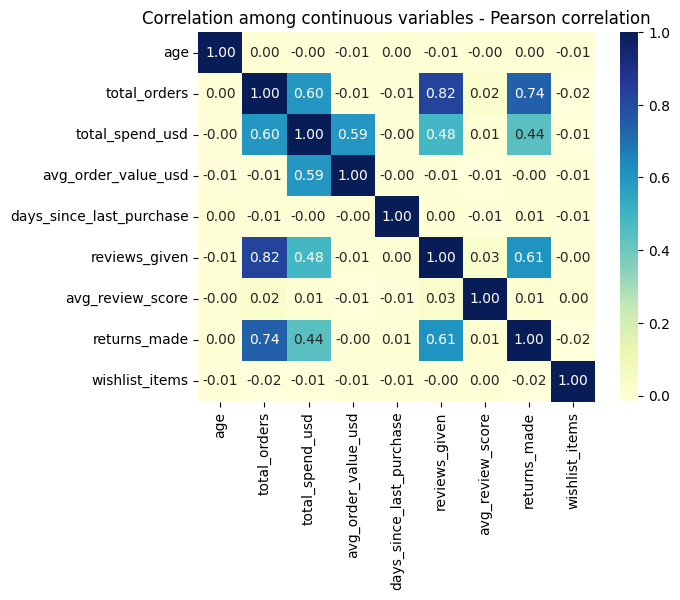

In [24]:
sns.heatmap(df[num_columns].corr(),fmt = '0.2f',annot = True,cmap="YlGnBu")
plt.title("Correlation among continuous variables - Pearson correlation")

Text(0.5, 1.0, 'Correlation among continuous variables - Spearman correlation')

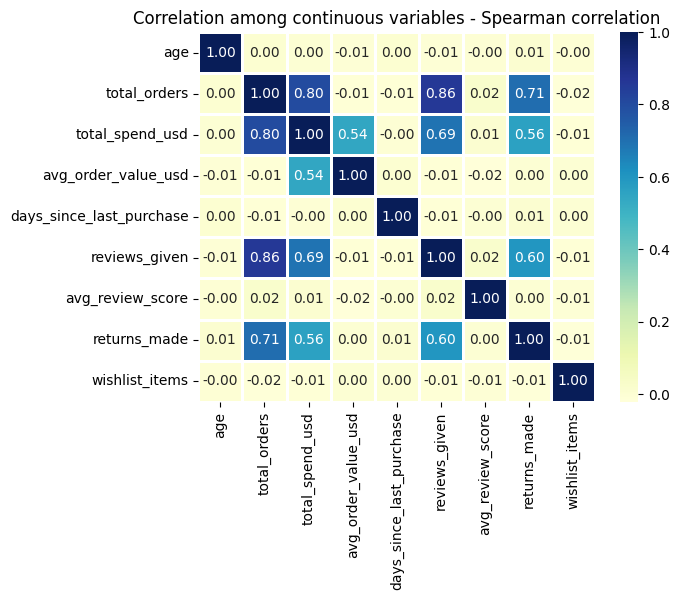

In [25]:
sns.heatmap(df[num_columns].corr(method = 'spearman'),fmt = '0.2f',annot = True, cmap="YlGnBu",linewidths = 1)
plt.title("Correlation among continuous variables - Spearman correlation")

The most counterintuitive was the correlation between "days since last purchase" and "total orders". Recent purchasers are not the frequent customers, it may be signalling that the company is losing customers.

No correlation of "age" with any other variables suggests that the dataset is either balanced or age is not factor for people to order online.

Correlation of 0 in many cases is either due to balanced dataset or the data is sparsely populated.

# Technical Cleaning

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.isna().sum()

customer_id                 0
country                     0
age                         0
gender                      0
membership_tier             0
registration_date           0
total_orders                0
total_spend_usd             0
avg_order_value_usd         0
days_since_last_purchase    0
preferred_category          0
preferred_device            0
preferred_payment_method    0
acquisition_channel         0
reviews_given               0
avg_review_score            0
returns_made                0
wishlist_items              0
newsletter_subscribed       0
churned                     0
dtype: int64

In [28]:
data = df.copy()

In [29]:
data

,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.8,0,0,1,0
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.2,0,8,1,0
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.0,4,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,C07996,United States,36,Male,Gold,2025-07-09,13,1953.76,175.38,40,Jewelry & Accessories,Tablet,Debit Card,Social Media,1,4.4,1,14,1,1
7996,C07997,India,42,Male,Free,2025-06-28,31,6772.20,251.76,53,Electronics,Mobile,Credit Card,Paid Ad,12,4.6,4,1,0,0
7997,C07998,India,34,Male,Platinum,2026-02-01,46,2430.09,58.01,18,Home & Kitchen,Desktop,Cryptocurrency,Organic Search,9,4.2,6,0,1,0
7998,C07999,Japan,44,Female,Free,2026-01-15,35,5552.56,147.22,50,Food & Grocery,Mobile,Credit Card,Paid Ad,10,4.1,1,2,0,0


In [30]:
data.drop(columns = ['customer_id','registration_date'],inplace = True)

In [31]:
data.head()

,country,age,gender,membership_tier,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,United States,40,Male,Free,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
1,United States,20,Female,Free,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
2,United States,43,Female,Gold,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.8,0,0,1,0
3,United States,41,Male,Free,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.2,0,8,1,0
4,France,37,Other,Platinum,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.0,4,5,1,0


In [32]:
from scipy.stats import stats
print(data[num_columns].skew())

age                         0.317999
total_orders                1.443741
total_spend_usd             6.146647
avg_order_value_usd         2.849029
days_since_last_purchase    2.046864
reviews_given               2.053239
avg_review_score           -0.759147
returns_made                2.317853
wishlist_items              1.885923
dtype: float64


other than age and avg_review_score, all have significant skewness and also positively skewed

Log transform the other features.

Will use PowerTransform to deal with outliers

In [33]:
from sklearn.model_selection import train_test_split

X = data.drop(columns = ['churned'],inplace = False)
y = data['churned']
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.2,random_state =123,stratify = y)

# Cleaning and model building

In [34]:
cat_columns.remove('customer_id')
cat_columns.remove('churned')
cat_columns.remove('newsletter_subscribed')

In [35]:
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [36]:
num_pipeline = Pipeline([('outlier_transform',PowerTransformer(method= 'yeo-johnson')),
                         ('pca',PCA())])
cat_pipeline = Pipeline([('ohe',OneHotEncoder(handle_unknown = 'ignore',sparse_output=False))])

preprocessor = ColumnTransformer(transformers = [('num',num_pipeline,num_columns),
                                                 ('cat',cat_pipeline,cat_columns)])

pipeline = Pipeline([('preprocessor',preprocessor),
                    ('clf',RandomForestClassifier())])

param_grid = {'preprocessor__num__pca__n_components':[0.90,0.95,0.99],
             'clf__n_estimators': [100, 200],
             'clf__max_depth': [None, 5, 10]}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)
print("Test score:", grid_search.score(X_test, y_test))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params: {'clf__max_depth': None, 'clf__n_estimators': 100, 'preprocessor__num__pca__n_components': 0.9}
Best CV score: 0.9109375
Test score: 0.911875
